In [1]:
# Lecture 2
# import packages
from scipy.stats import t
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
# os.chdir(r'C:\Users\Linda\Desktop\ST5213py')
pd.set_option("display.width", 2000)

# fig_save_dir = r"C:/Users/Linda/OneDrive - National University of Singapore/ST5213 2627/Lectures/Lecture_2/figure"

In [2]:
# read and preprocess gavote dataset
df = pd.read_csv('dataset/gavote.txt', sep=' ')

# add variable undercount to df
df['undercount'] = (df['ballots'] - df['votes']) / df['ballots']

# add variable pergore to df
df['pergore'] = df['gore'] / df['votes']

# center pergore and perAA for ease of interpretation 
df['pergore'] = df['pergore'] - df['pergore'].mean()
df['perAA'] = df['perAA'] - df['perAA'].mean()

# Assign multiple columns as categorical 
cols_to_cat = ['equip', 'econ', 'rural', 'atlanta']
df[cols_to_cat] = df[cols_to_cat].astype('category')

print(df.head(), '\n')
print(df.info()) 

          equip    econ     perAA  rural     atlanta  gore  bush  other  votes  ballots  undercount   pergore
APPLING   LEVER    poor -0.060981  rural  notAtlanta  2093  3940     66   6099     6617    0.078283 -0.065151
ATKINSON  LEVER    poor -0.012981  rural  notAtlanta   821  1228     22   2071     2149    0.036296 -0.011895
BACON     LEVER    poor -0.111981  rural  notAtlanta   956  2010     29   2995     3347    0.105169 -0.089123
BAKER     OS-CC    poor  0.233019  rural  notAtlanta   893   615     11   1519     1607    0.054760  0.179565
BALDWIN   LEVER  middle  0.116019  rural  notAtlanta  5893  6041    192  12126    12785    0.051545  0.077659 

<class 'pandas.DataFrame'>
Index: 159 entries, APPLING to WORTH
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   equip       159 non-null    category
 1   econ        159 non-null    category
 2   perAA       159 non-null    float64 
 3   rural       159 non-null  

In [3]:
# Fit linear regression model
fm = ols(formula='undercount ~ pergore + perAA', data=df).fit()
print(fm.summary2())
# Exclude intercept: 'undercount ~ pergore + perAA - 1'

                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.041     
Dependent Variable: undercount       AIC:                -725.9576 
Date:               2026-09-01 16:20 BIC:                -716.7509 
No. Observations:   159              Log-Likelihood:     365.98    
Df Model:           2                F-statistic:        4.373     
Df Residuals:       156              Prob (F-statistic): 0.0142    
R-squared:          0.053            Scale:              0.00059775
---------------------------------------------------------------------
              Coef.    Std.Err.      t      P>|t|     [0.025   0.975]
---------------------------------------------------------------------
Intercept     0.0438     0.0019   22.5856   0.0000    0.0400   0.0476
pergore       0.0110     0.0469    0.2340   0.8153   -0.0817   0.1037
perAA         0.0285     0.0307    0.9283   0.3547   -0.0322   0.0892
------------------------------------------------------

In [4]:
# Coefficients 
print(fm.params, '\n')

# Standard errors 
print(fm.bse, '\n')     # beta standard errors

# Fitted values 
fitted = fm.fittedvalues
print(fitted.head())    # pandas.Series

Intercept    0.043792
pergore      0.010979
perAA        0.028533
dtype: float64 

Intercept    0.001939
pergore      0.046922
perAA        0.030738
dtype: float64 

APPLING     0.041337
ATKINSON    0.043291
BACON       0.039618
BAKER       0.052412
BALDWIN     0.047955
dtype: float64


In [5]:
# residuals
resid = fm.resid
print(resid.head(), '\n')          # pandas.Series

# Residual sum of squares
RSS = fm.ssr
print(RSS)

print(sum(resid**2),  '\n')

# Residual degrees of freedom 
df_resid = fm.df_resid 
print(df_resid)                       # 159 - 3    

APPLING     0.036947
ATKINSON   -0.006995
BACON       0.065551
BAKER       0.002348
BALDWIN     0.003590
dtype: float64 

0.09324917740978239
0.09324917740978239 

156.0


In [6]:
# Estimate of sigma            
sigma = np.sqrt(fm.scale)
print(sigma)

np.sqrt(RSS/df_resid)

0.02444894961429212


np.float64(0.02444894961429212)

In [7]:
# Rsq and adjusted Rsq 
print(fm.rsquared)
print(fm.rsquared_adj)

0.05308860901036749
0.04094871938229527


In [8]:
# F-test
print(f'F-statistic: {fm.fvalue:.3f} on {fm.df_model} and {fm.df_resid} DF, p-value: {fm.f_pvalue:.3f}')

F-statistic: 4.373 on 2.0 and 156.0 DF, p-value: 0.014


In [9]:
# returns a sorted list of valid attributes and methods for fitted model
dir(fm)

['HC0_se',
 'HC1_se',
 'HC2_se',
 'HC3_se',
 '_HCCM',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abat_diagonal',
 '_cache',
 '_data_attr',
 '_data_in_cache',
 '_get_robustcov_results',
 '_get_wald_nonlinear',
 '_is_nested',
 '_nobs_int',
 '_summary_cache',
 '_transform_predict_exog',
 '_use_t',
 '_wexog_singular_values',
 'aic',
 'bic',
 'bse',
 'centered_tss',
 'compare_f_test',
 'compare_lm_test',
 'compare_lr_test',
 'condition_number',
 'conf_int',
 'conf_int_el',
 'cov_HC0',
 'cov_HC1',
 'cov_HC2',
 'cov_HC3',
 'cov_kwds',
 'cov_params',
 'cov_type',
 'df_model',
 'df_resid',
 'eigenvals',
 'el_test',
 'ess',
 'f_pvalue',
 'f_test',
 'fitte

In [10]:
# fit null model
fm0 = ols(formula='undercount ~ 1', data=df).fit()
print(fm0.summary2())

                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     -0.000    
Dependent Variable: undercount       AIC:                -721.2842 
Date:               2026-09-01 16:20 BIC:                -718.2153 
No. Observations:   159              Log-Likelihood:     361.64    
Df Model:           0                F-statistic:        nan       
Df Residuals:       158              Prob (F-statistic): nan       
R-squared:          -0.000           Scale:              0.00062327
---------------------------------------------------------------------
               Coef.    Std.Err.      t      P>|t|    [0.025   0.975]
---------------------------------------------------------------------
Intercept      0.0438     0.0020   22.1183   0.0000   0.0399   0.0477
-------------------------------------------------------------------
Omnibus:               83.846       Durbin-Watson:          1.936  
Prob(Omnibus):         0.000        Jarque-Bera (JB):     

In [11]:
# compare fm and fm0 using anova
print(anova_lm(fm0, fm))

   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0     158.0  0.098477      0.0       NaN       NaN       NaN
1     156.0  0.093249      2.0  0.005228  4.373072  0.014195


In [12]:
# t-test statistics
t_stat = fm.tvalues 
print(t_stat, '\n')
print(fm.params/fm.bse, '\n')

# t-test p-values
print(fm.pvalues)
pvals = 2 * t.sf(np.abs(t_stat), df_resid)
print(np.round(pvals, 3))

Intercept    22.585607
pergore       0.233978
perAA         0.928272
dtype: float64 

Intercept    22.585607
pergore       0.233978
perAA         0.928272
dtype: float64 

Intercept    4.885829e-51
pergore      8.153090e-01
perAA        3.547007e-01
dtype: float64
[0.    0.815 0.355]


In [13]:
# fit model with only pergore 
fm1 = ols(formula='undercount ~ pergore', data=df).fit()
print(anova_lm(fm1, fm))

   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0     157.0  0.093764      0.0       NaN       NaN       NaN
1     156.0  0.093249      1.0  0.000515  0.861689  0.354701


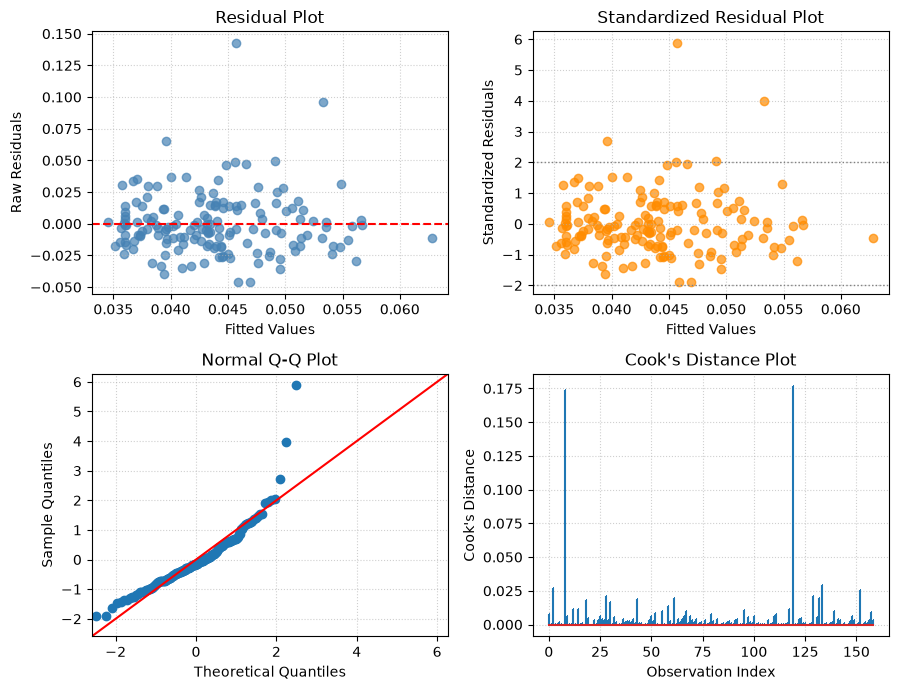

In [14]:
# Diagnostic plots
influence = fm.get_influence()
std_resid = influence.resid_studentized_internal
cooks_distances, _ = influence.cooks_distance

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Residual Plot
axes[0, 0].scatter(fitted, resid, alpha=0.7, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('Residual Plot')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Raw Residuals')
axes[0, 0].grid(True, linestyle=':', alpha=0.6)

# Standardized Residual Plot
axes[0, 1].scatter(fitted, std_resid, alpha=0.7, color='darkorange')
axes[0, 1].axhline(y=2, color='gray', linestyle=':', linewidth=1)
axes[0, 1].axhline(y=-2, color='gray', linestyle=':', linewidth=1)
axes[0, 1].set_title('Standardized Residual Plot')
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Standardized Residuals')
axes[0, 1].grid(True, linestyle=':', alpha=0.6)

# Q-Q Plot
sm.qqplot(resid, line='45', fit=True, ax=axes[1, 0])
axes[1, 0].set_title('Normal Q-Q Plot')
axes[1, 0].grid(True, linestyle=':', alpha=0.6)

# Cook's Distance Plot
axes[1, 1].stem(np.arange(len(cooks_distances)), cooks_distances, markerfmt=",")
axes[1, 1].set_title("Cook's Distance Plot")
axes[1, 1].set_xlabel('Observation Index')
axes[1, 1].set_ylabel("Cook's Distance")
axes[1, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "diagnostics.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  

plt.show()

In [15]:
print(df['equip'].value_counts())
fm2 = ols(formula='undercount ~ equip', data=df).fit()
print(fm2.summary2())
print(fm2.model.exog[:10,:])           # X matrix
print(df.head(10))

equip
LEVER    74
OS-CC    44
OS-PC    22
PUNCH    17
PAPER     2
Name: count, dtype: int64
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     -0.006    
Dependent Variable: undercount       AIC:                -716.4637 
Date:               2026-09-01 16:21 BIC:                -701.1192 
No. Observations:   159              Log-Likelihood:     363.23    
Df Model:           4                F-statistic:        0.7776    
Df Residuals:       154              Prob (F-statistic): 0.541     
R-squared:          0.020            Scale:              0.00062680
--------------------------------------------------------------------
                  Coef.   Std.Err.     t     P>|t|    [0.025  0.975]
--------------------------------------------------------------------
Intercept         0.0419    0.0029  14.3946  0.0000   0.0361  0.0476
equip[T.OS-CC]    0.0001    0.0048   0.0190  0.9849  -0.0093  0.0095
equip[T.OS-PC]    0.0097    0.0061   

In [16]:
# Read pollen dataset
pollen = pd.read_csv('dataset/pollen.txt', sep=' ')
print(pollen, '\n')

# Convert Depth and Sample to categorical variables
cols_to_cat = ['Depth', 'Sample']
pollen[cols_to_cat] = pollen[cols_to_cat].astype('category')
print(pollen.info(), '\n') 

print(pollen['Depth'].cat.categories, '\n')
print(pollen['Sample'].cat.categories, '\n')

      Depth Sample  Count
0   shallow      A     12
1   shallow      A     14
2   shallow      B     10
3   shallow      B      7
4    medium      A     16
5    medium      A     12
6    medium      B     10
7    medium      B     19
8      deep      A     21
9      deep      A     29
10     deep      B     33
11     deep      B     30 

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Depth   12 non-null     category
 1   Sample  12 non-null     category
 2   Count   12 non-null     int64   
dtypes: category(2), int64(1)
memory usage: 292.0 bytes
None 

Index(['deep', 'medium', 'shallow'], dtype='str') 

Index(['A', 'B'], dtype='str') 



In [17]:
fm3 = ols(formula='Count ~ Depth/Sample', data=pollen).fit()
print(fm3.summary2())

                      Results: Ordinary least squares
Model:                  OLS                  Adj. R-squared:         0.800  
Dependent Variable:     Count                AIC:                    70.4317
Date:                   2026-09-01 16:22     BIC:                    73.3412
No. Observations:       12                   Log-Likelihood:         -29.216
Df Model:               5                    F-statistic:            9.820  
Df Residuals:           6                    Prob (F-statistic):     0.00746
R-squared:              0.891                Scale:                  15.250 
----------------------------------------------------------------------------
                            Coef.   Std.Err.    t    P>|t|   [0.025   0.975]
----------------------------------------------------------------------------
Intercept                   25.0000   2.7613  9.0536 0.0001  18.2432 31.7568
Depth[T.medium]            -11.0000   3.9051 -2.8168 0.0305 -20.5555 -1.4445
Depth[T.shallow]      

In [18]:
def sum_sq(x):
    return sum((x - np.mean(x)) ** 2)

Count = np.array(pollen['Count'])

# Null model
RSS_N = sum_sq(Count) 
print(RSS_N)

# Reduced model
RSS_R = sum_sq(Count[range(4)]) + sum_sq(Count[range(4,8)]) + sum_sq(Count[range(8,12)])
print(RSS_R)

# Full model
RSS_F = (sum_sq(Count[range(0,2)]) + sum_sq(Count[range(2,4)]) + sum_sq(Count[range(4,6)]) 
         + sum_sq(Count[range(6,8)]) + sum_sq(Count[range(8,10)]) + sum_sq(Count[range(10, 12)]))
print(RSS_F)

print(RSS_N - RSS_R)  # RSS explained by Depth
print(RSS_R - RSS_F)  # RSS explained by Depth:Sample given Depth is already in model

840.25
154.25
91.5
686.0
62.75


In [19]:
print(anova_lm(fm3))

               df  sum_sq     mean_sq          F    PR(>F)
Depth         2.0  686.00  343.000000  22.491803  0.001630
Depth:Sample  3.0   62.75   20.916667   1.371585  0.338472
Residual      6.0   91.50   15.250000        NaN       NaN


In [20]:
fm4 = ols(formula='Count ~ Depth', data=pollen).fit()
print(anova_lm(fm4))

           df  sum_sq     mean_sq          F    PR(>F)
Depth     2.0  686.00  343.000000  20.012966  0.000487
Residual  9.0  154.25   17.138889        NaN       NaN


In [21]:
# AIC: prefer fm6
fm6 = ols('undercount ~ equip * econ + equip * perAA + rural * perAA', df).fit()
print(fm6.aic)
fm7 = ols('undercount ~ equip * econ + equip * perAA + rural', data=df).fit()
print(fm7.aic)        

# F-test: prefer fm7
print(anova_lm(fm7, fm6))

-779.9194797901531
-778.9196408522533
   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0     140.0  0.054649      0.0       NaN       NaN       NaN
1     139.0  0.053627      1.0  0.001021  2.647396  0.105984


C:\Users\YuxinLi\AppData\Local\Temp\ipykernel_20816\1957122605.py:2: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fm6 = ols('undercount ~ equip * econ + equip * perAA + rural * perAA', df).fit()
C:\Users\YuxinLi\AppData\Local\Temp\ipykernel_20816\1957122605.py:4: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  fm7 = ols('undercount ~ equip * econ + equip * perAA + rural', data=df).fit()
